In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [3]:
# df = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/fold1_selected_genomic_windows_centered.tsv", sep="\t")

df = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/fold1_chromatin_state_fractions.tsv", sep="\t")

In [4]:
df = df.rename(columns={"centered_start_query": "centered_start", "centered_end_query": "centered_end", "chrom_query": "chrom"})

In [16]:
df

,chrom,start_query,end_query,centered_start,centered_end,active_count,neutral_count,repressive_count,total,active_fraction,neutral_fraction,repressive_fraction
0,chr1,51017728,51267584,50487296,51798016,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
1,chr1,55470080,55678976,54919168,56229888,0.0,3.0,2.0,5.0,0.000000,0.600000,0.400000
2,chr1,62328832,62640128,61829120,63139840,1.0,6.0,3.0,10.0,0.100000,0.600000,0.300000
3,chr1,66222080,66426880,65669120,66979840,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
4,chr1,68665344,69062656,68208640,69519360,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
72,chr7,136146944,136372224,135604224,136914944,4.0,27.0,22.0,53.0,0.075472,0.509434,0.415094
73,chr7,136548352,136769536,136003584,137314304,3.0,39.0,35.0,77.0,0.038961,0.506494,0.454545
74,chr7,140296192,140627968,139806720,141117440,0.0,1.0,0.0,1.0,0.000000,1.000000,0.000000
75,chr8,10625024,10919936,10117120,11427840,6.0,57.0,49.0,112.0,0.053571,0.508929,0.437500


In [5]:
class OriginalDataset(Dataset):
    def __init__(self, coord_df, init_seq_path):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
    
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True)
        X = X.squeeze(0)
        return X

In [6]:
class BoundaryGenerationDataset(Dataset):
    def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
        self.slice_path = slice_path
        self.slice = slice
        self.cropping = cropping
        self.bin_size = bin_size
        
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True)
        slice = torch.load(f"{self.slice_path}{chrom}_{start}_{end}_slice.pt", weights_only=True)
        
        edit_start = (self.slice + self.cropping) * self.bin_size
        edit_end = edit_start + self.bin_size
        
        editedX = X.clone()
        editedX[:,:, edit_start:edit_end] = slice
        
        editedX = editedX.squeeze(0)
        
        return editedX

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [8]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_878811/ipykernel_1615799/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [9]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [10]:
orig_dataset = OriginalDataset(df, "/scratch1/smaruj/genomic_insertion_loci/ohe_X/")
orig_loader = DataLoader(orig_dataset, batch_size=4, shuffle=False)

In [11]:
edited_dataset = BoundaryGenerationDataset(df, 
                                "/scratch1/smaruj/genomic_insertion_loci/ohe_X/", 
                                "/scratch1/smaruj/genomic_insertion_loci/results/")

edited_loader = DataLoader(edited_dataset, batch_size=4, shuffle=False)

In [12]:
preds_all_orig = []
preds_all_edited = []
scd_values = []
urq_mean_values = []

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        preds_orig = model(orig_batch).cpu()
        preds_edited = model(edited_batch).cpu()

        preds_all_orig.extend(preds_orig)
        preds_all_edited.extend(preds_edited)
        
        scd_batch = torch.sqrt(((preds_edited - preds_orig) ** 2).sum(dim=(1, 2)))  # [B]
        scd_values.extend(scd_batch.numpy())
        
        orig_maps = from_upper_triu_batch(preds_orig)
        edited_maps = from_upper_triu_batch(preds_edited)
        difference = edited_maps - orig_maps
        
        urq_mean = np.nanmean(difference[:, 0:250, 260:512], axis=(1, 2))
        urq_mean_values.extend(urq_mean)

In [13]:
orig_preds_all = torch.cat(preds_all_orig, dim=0)
edited_preds_all = torch.cat(preds_all_edited, dim=0)

In [14]:
import matplotlib.pyplot as plt

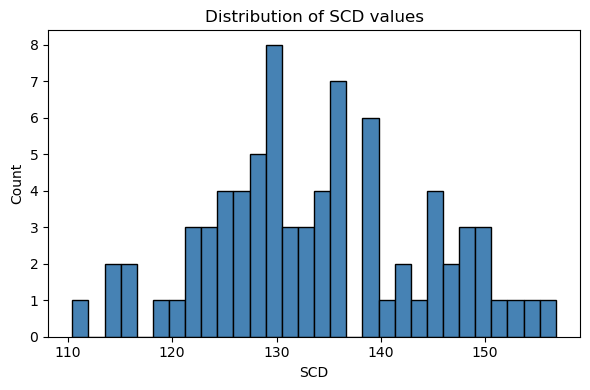

In [15]:
plt.figure(figsize=(6, 4))
plt.hist(scd_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("SCD")
plt.ylabel("Count")
plt.title("Distribution of SCD values")
plt.tight_layout()
plt.show()

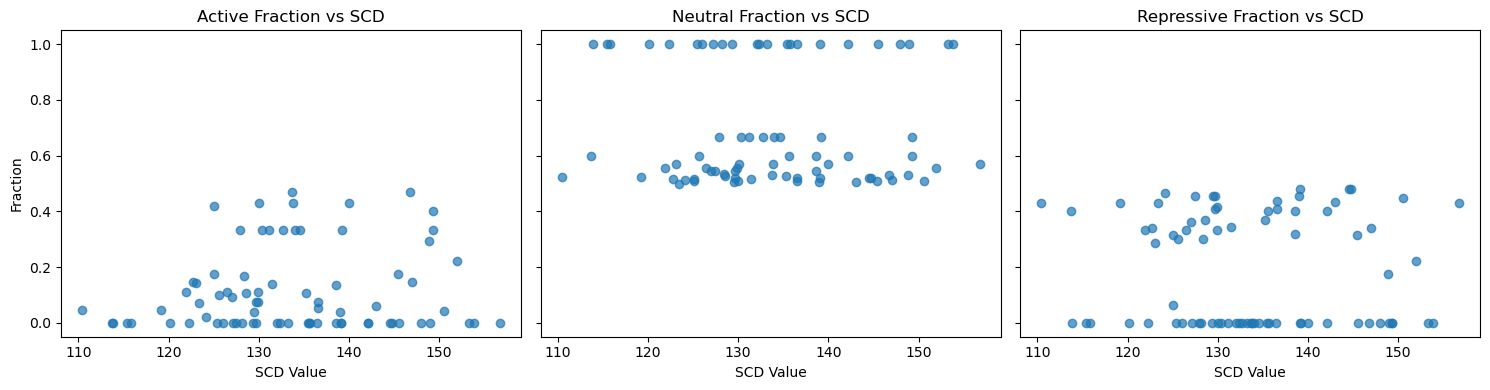

In [17]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(scd_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(scd_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs SCD")
    axes[i].set_xlabel("SCD Value")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

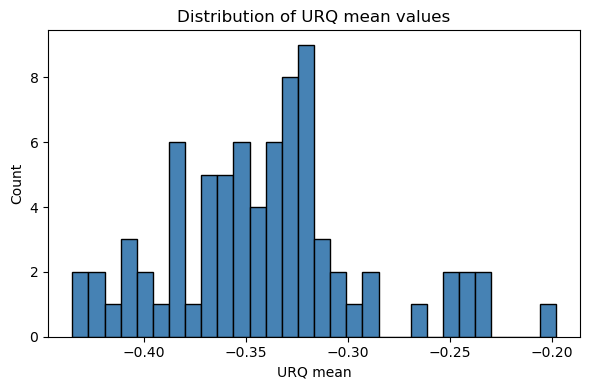

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("URQ mean")
plt.ylabel("Count")
plt.title("Distribution of URQ mean values")
plt.tight_layout()
plt.show()

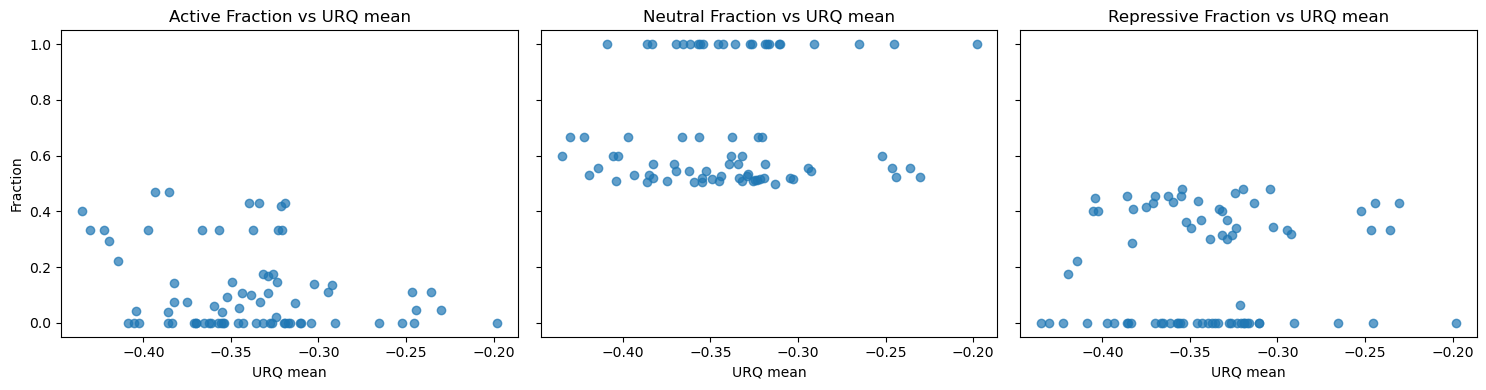

In [19]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(urq_mean_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(urq_mean_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs URQ mean")
    axes[i].set_xlabel("URQ mean")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

In [20]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [21]:
import matplotlib.pyplot as plt

0


<Figure size 500x500 with 0 Axes>

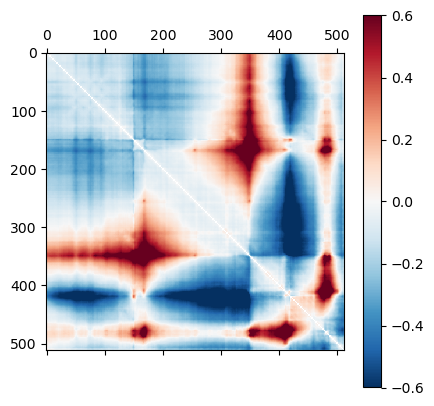

1


<Figure size 500x500 with 0 Axes>

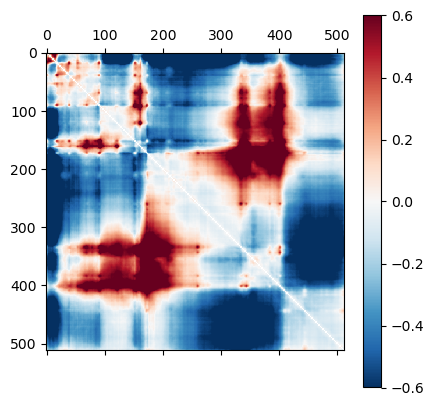

2


<Figure size 500x500 with 0 Axes>

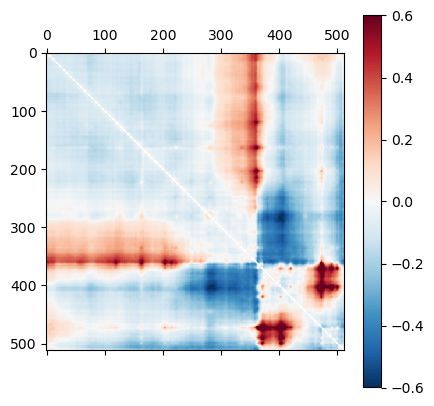

3


<Figure size 500x500 with 0 Axes>

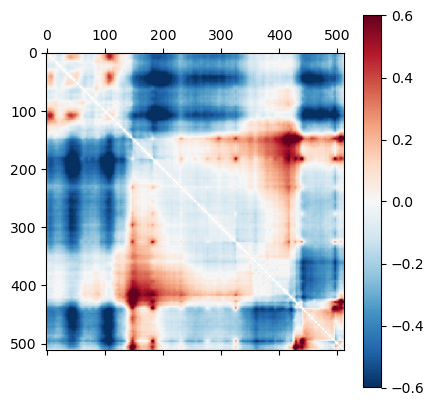

In [22]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

0


<Figure size 500x500 with 0 Axes>

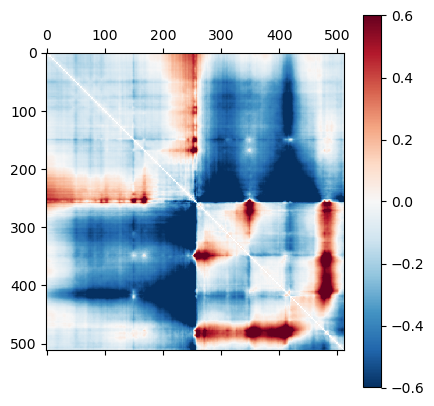

1


<Figure size 500x500 with 0 Axes>

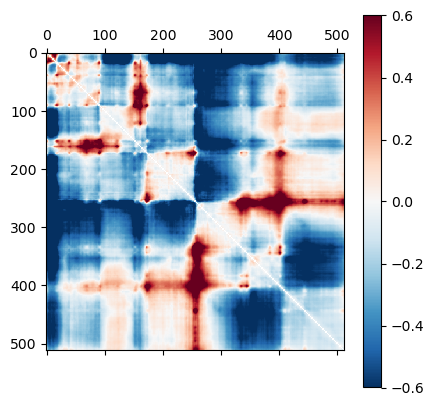

2


<Figure size 500x500 with 0 Axes>

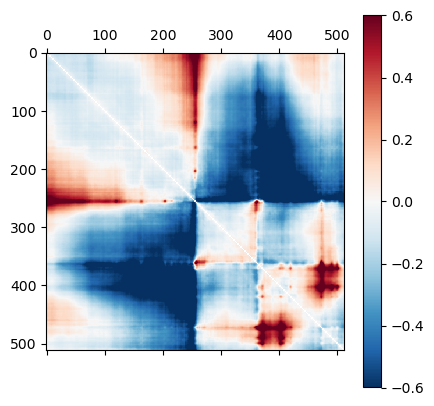

3


<Figure size 500x500 with 0 Axes>

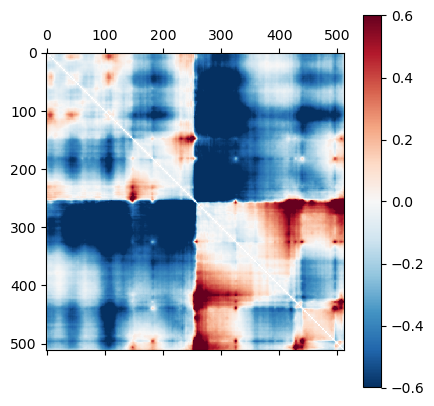

In [23]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

0


<Figure size 500x500 with 0 Axes>

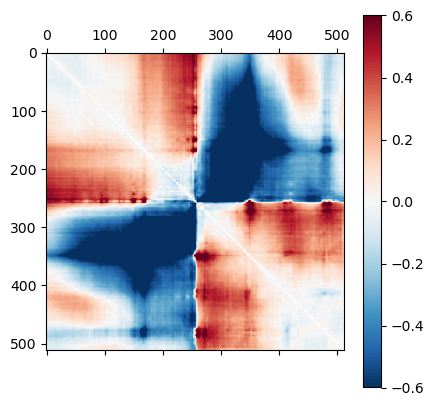

1


<Figure size 500x500 with 0 Axes>

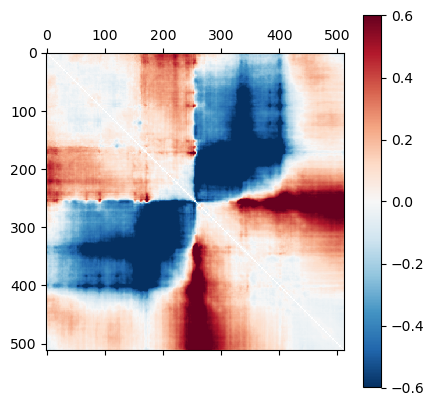

2


<Figure size 500x500 with 0 Axes>

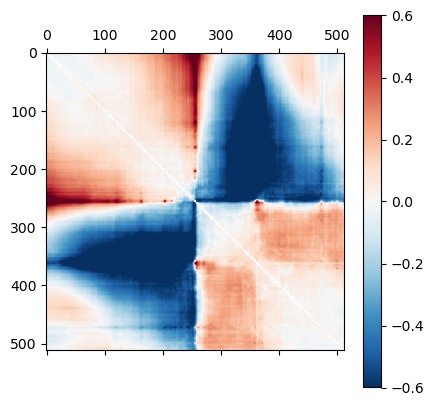

3


<Figure size 500x500 with 0 Axes>

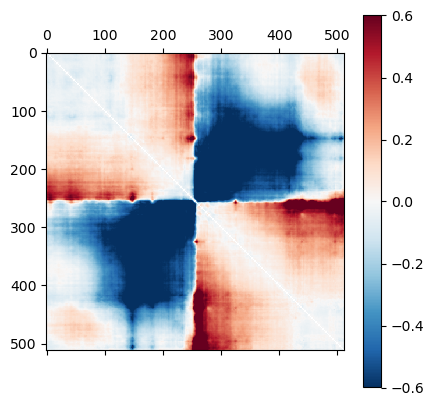

In [24]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:] - orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()